In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import numpy as np

print("Done")

Done


In [2]:
# Load dataset
df = pd.read_csv(
    "Processed_data.csv",
    dtype={"StateHoliday": str}
)


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 844338 entries, 0 to 844337
Data columns (total 18 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   Store                      844338 non-null  int64  
 1   DayOfWeek                  844338 non-null  int64  
 2   Date                       844338 non-null  str    
 3   Sales                      844338 non-null  int64  
 4   Customers                  844338 non-null  int64  
 5   Open                       844338 non-null  int64  
 6   Promo                      844338 non-null  int64  
 7   StateHoliday               844338 non-null  str    
 8   SchoolHoliday              844338 non-null  int64  
 9   StoreType                  844338 non-null  str    
 10  Assortment                 844338 non-null  str    
 11  CompetitionDistance        842152 non-null  float64
 12  CompetitionOpenSinceMonth  575738 non-null  float64
 13  CompetitionOpenSinceYear   575738 non-nu

In [4]:
# Handling the null values in the columns

df["CompetitionDistance"] = df["CompetitionDistance"].fillna(
    df["CompetitionDistance"].mean()
)


In [5]:
df["CompetitionOpenSinceMonth"] = df["CompetitionOpenSinceMonth"].fillna(
    df["CompetitionOpenSinceMonth"].mean()
)

In [6]:
df["CompetitionOpenSinceYear"] = df["CompetitionOpenSinceYear"].fillna(
    df["CompetitionOpenSinceYear"].mean()
)

In [7]:
df["Promo2SinceWeek"] = df["Promo2SinceWeek"].fillna(
    df["Promo2SinceWeek"].mean()
)

In [8]:
df["Promo2SinceYear"] = df["Promo2SinceYear"].fillna(
    df["Promo2SinceYear"].mean()
)

In [9]:
df["PromoInterval"] = df["PromoInterval"].fillna("NoPromo")

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 844338 entries, 0 to 844337
Data columns (total 18 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   Store                      844338 non-null  int64  
 1   DayOfWeek                  844338 non-null  int64  
 2   Date                       844338 non-null  str    
 3   Sales                      844338 non-null  int64  
 4   Customers                  844338 non-null  int64  
 5   Open                       844338 non-null  int64  
 6   Promo                      844338 non-null  int64  
 7   StateHoliday               844338 non-null  str    
 8   SchoolHoliday              844338 non-null  int64  
 9   StoreType                  844338 non-null  str    
 10  Assortment                 844338 non-null  str    
 11  CompetitionDistance        844338 non-null  float64
 12  CompetitionOpenSinceMonth  844338 non-null  float64
 13  CompetitionOpenSinceYear   844338 non-nu

In [11]:
# date related features engineering
df["Date"] = pd.to_datetime(df["Date"])

df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["WeekOFYear"] = df["Date"].dt.isocalendar().week
df["Quarter"] = df["Date"].dt.quarter

#specifying weekend encoder
df["IsWeekend"] = np.where(
    df["DayOfWeek"].isin([6,7]),
    1,
    0
)


#### __Observation__

Grouped daily sales analysis reveals noticeable variation in sales behavior across different days of the month. The begining and end of month, particularlly days 1, 2, 30 and 31, exhibit higher average sales levels compared to several mid-month periods.
In contrast, lower average sales activity appears during portions of the later mid-month interval, particularly arround days 23-27. These recurring fluctuations may reflect cyclical consumer purchase behavior associated with monthly budgeting or salary-payment patterns.
The result suggests that the engineed "Day" feature captures meaningful intra-month temporal dynamics and may provide useful predictive signal for the forecasting model.


In [12]:
# New feature Month group analysis

df.groupby("Month")["Sales"].mean()



Month
1     6564.298651
2     6589.494012
3     6976.817749
4     7046.659509
5     7106.808038
6     7001.402127
7     6953.575827
8     6649.229053
9     6547.469104
10    6602.967255
11    7188.554250
12    8608.956661
Name: Sales, dtype: float64

#### __Observation__
Grouped monthly sales analysis reveals noticeably saeson variation throughout the year. December  exhibits the highest average sales levels, suggesting a strong holiday-season effect likeky associated with christmas purchasing behavior.
Several mid-year months also display elevated sales activity, indicating the precesence of recurrimg seaseonal demand patterns. These results suggest that the engineered "Month" feature captures meaningful temporal dynamics and may provide predictive value for the forcasting model.

In [13]:
# New feature quarter group analysis

df.groupby("Quarter")["Sales"].mean()

Quarter
1    6712.737093
2    7051.082207
3    6756.975986
4    7448.874862
Name: Sales, dtype: float64

#### __Observation__

Grouped Quarterly analysis further confirms the presence of seasonal variation throughout the dataset, supporting the previously observed monthly sales patterns. Quarter 4 exhibits the highest average sales levels, reinforcing the presence of strong end-of-year demand effects, while Quartly 2 also maintains elevated elevated sales activaty.
These results suggests that the engineered "Quarter" feature captures broader seasonal purchase behavior and may conteibute useful temporal signal for the forecasting model.

In [14]:
# New feature Year group analysis
df.groupby("Year")["Sales"].mean()

Year
2013    6814.775168
2014    7026.128505
2015    7088.235123
Name: Sales, dtype: float64

#### __Observation__

We Grouping yearly sales analysis indicates moderate variation in average sales levels across the avaliable time periods. The result suggests the presence of temporal trend dynamics within the dataset, althogh interpretation should be made cautiously because the dataset does not contain complet observations for all years.
Nevertheless, the engineered "Year" feature may still provide usefull long-term temporal context for the forecasting model by capturing broader changes in sales behavior over time


In [15]:
# Feature engineering from competition opening columns 
# into competition duration at time of sale


#Create a competition opening date from month and year
df["CompetitionOpenDate"] = pd.to_datetime(
    dict(
        year=df["CompetitionOpenSinceYear"].astype(int),
        month=df["CompetitionOpenSinceMonth"].astype(int),
        day =1
    )
)

# Engenieer duration: how many month the competition has been open

df["CompetitionOpenDurationMonths"] = (
    (df["Date"].dt.year - df["CompetitionOpenDate"].dt.year) * 12
    + (df["Date"].dt.month - df["CompetitionOpenDate"].dt.month)
)

# Avoid negative values if competition if competition date is after the sale
df["CompetitionOpenDurationMonths"] = df["CompetitionOpenDurationMonths"].clip(lower=0)

# Drop original competition date columns and temporary helper column
df.drop(
    columns=[
        "CompetitionOpenSinceMonth",
        "CompetitionOpenSinceYear",
        "CompetitionOpenDate"
    ],
    inplace = True
)

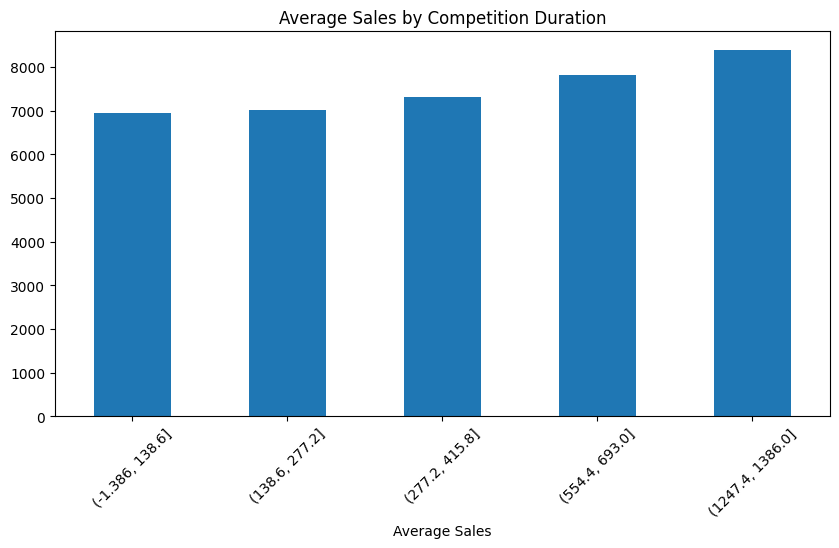

In [16]:
# visualy plot of influence of duration months on sales
# Group competition duration into intervals

competition_bins = pd.cut(
    df["CompetitionOpenDurationMonths"],
    bins = 10
)

# Plot average sales by competition duration groups

df.groupby(competition_bins)["Sales"].mean().plot(
    kind = "bar",
    figsize = (10,5)
)

plt.title("Average Sales by Competition Duration")
plt.xlabel("Competition Duration(Months)")
plt.xlabel("Average Sales")
plt.xticks(rotation=45)

plt.show()






#### __Observation__

The Engineered CompetitionOpenDurationMonths feature reveals a gradual upward trend in average sales as the duration of the local competition increases. Stores facing newly established competition tend to exhibit lower average sales, while stores operating in competitive enviroments for longer periods show progressively stronger sales performsnce. This patterrn may suggest that stores adapt over time to competition pressure through customer retention, operational adjustments, or market stabilization effects. THe observed trend indicates that the competition duration captures meaningful business dynamics and can provide usefull predictive signal for the forecasting model.

In [17]:
# Engineer features to separate Sunday effects from general weekend behavior,
# since only a limited subset of stores operate on Sundays

#Seperate Sunday from general weekend
df["IsSunday"] = (df["DayOfWeek"] == 7).astype(int)
df["IsSaturday"] = (df["DayOfWeek"] == 6).astype(int)

# Interception: store is open on sunday
df["OpenOnSunday"] = ((df["DayOfWeek"] == 7) & (df["Open"] ==1)).astype(int)


In [18]:
# Sunday values validation control
df.groupby("OpenOnSunday")["Sales"].mean()

OpenOnSunday
0    6950.536952
1    8224.723908
Name: Sales, dtype: float64

## __Observation__
The engineered OpenOnSunday feature confirms that stores operating on Sundays generate substantially higher average sales compared to regular observations. This supports the earlier EDA findings that Sunday sales behavior is heavily influenced by the limited number of stores remaining open, concentrating customer demand into a smaller subset of active stores. The feature successfully captures this operational effect and may provide valuable predictive signal for the forecasting model.

In [19]:
# Verification before moddeling
df.describe()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,SchoolHoliday,CompetitionDistance,Promo2,...,Year,Month,Day,WeekOFYear,Quarter,IsWeekend,CompetitionOpenDurationMonths,IsSunday,IsSaturday,OpenOnSunday
count,844338.000000,844338.000000,844338,844338.000000,844338.000000,844338.0,844338.000000,844338.000000,844338.000000,844338.000000,...,844338.000000,844338.000000,844338.000000,844338.0,844338.000000,844338.000000,844338.000000,844338.000000,844338.000000,844338.000000
mean,558.421374,3.520350,2014-04-11 01:08:38.729703,6955.959134,762.777166,1.0,0.446356,0.193578,5458.156627,0.498670,...,2013.831945,5.845774,15.835706,23.646946,2.296006,0.174865,63.851518,0.004255,0.170609,0.004255
min,1.000000,1.000000,2013-01-01 00:00:00,46.000000,8.000000,1.0,0.000000,0.000000,20.000000,0.000000,...,2013.000000,1.000000,1.000000,1.0,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,280.000000,2.000000,2013-08-16 00:00:00,4859.000000,519.000000,1.0,0.000000,0.000000,710.000000,0.000000,...,2013.000000,3.000000,8.000000,11.0,1.000000,0.000000,29.000000,0.000000,0.000000,0.000000
50%,558.000000,3.000000,2014-03-31 00:00:00,6369.000000,676.000000,1.0,0.000000,0.000000,2330.000000,0.000000,...,2014.000000,6.000000,16.000000,23.0,2.000000,0.000000,63.000000,0.000000,0.000000,0.000000
75%,837.000000,5.000000,2014-12-11 00:00:00,8360.000000,893.000000,1.0,1.000000,0.000000,6880.000000,1.000000,...,2014.000000,8.000000,23.000000,35.0,3.000000,0.000000,81.000000,0.000000,0.000000,0.000000
max,1115.000000,7.000000,2015-07-31 00:00:00,41551.000000,7388.000000,1.0,1.000000,1.000000,75860.000000,1.000000,...,2015.000000,12.000000,31.000000,52.0,4.000000,1.000000,1386.000000,1.000000,1.000000,1.000000
std,321.730861,1.723712,NaN,3103.815515,401.194153,0.0,0.497114,0.395102,7799.457083,0.499999,...,0.777271,3.323959,8.683392,14.389931,1.083494,0.379852,58.873037,0.065095,0.376168,0.065095


In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 844338 entries, 0 to 844337
Data columns (total 26 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   Store                          844338 non-null  int64         
 1   DayOfWeek                      844338 non-null  int64         
 2   Date                           844338 non-null  datetime64[us]
 3   Sales                          844338 non-null  int64         
 4   Customers                      844338 non-null  int64         
 5   Open                           844338 non-null  int64         
 6   Promo                          844338 non-null  int64         
 7   StateHoliday                   844338 non-null  str           
 8   SchoolHoliday                  844338 non-null  int64         
 9   StoreType                      844338 non-null  str           
 10  Assortment                     844338 non-null  str           
 11  Competition

In [21]:
df.isnull().sum()

Store                            0
DayOfWeek                        0
Date                             0
Sales                            0
Customers                        0
Open                             0
Promo                            0
StateHoliday                     0
SchoolHoliday                    0
StoreType                        0
Assortment                       0
CompetitionDistance              0
Promo2                           0
Promo2SinceWeek                  0
Promo2SinceYear                  0
PromoInterval                    0
Year                             0
Month                            0
Day                              0
WeekOFYear                       0
Quarter                          0
IsWeekend                        0
CompetitionOpenDurationMonths    0
IsSunday                         0
IsSaturday                       0
OpenOnSunday                     0
dtype: int64

## __DATASET READY FOR MODELLING__
#### Creation of dataset with already engineered feature ready for modelling
#### df.to_csv("Modelling_data.csv", index = False)